In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/modma-dataset-2/audio_lanzhou_2015/audio_lanzhou_2015/MODMA dataset-a Multi-modal Open Dataset for Mental-disorder Analysis.pdf
/kaggle/input/modma-dataset-2/audio_lanzhou_2015/audio_lanzhou_2015/subjects_information_audio_lanzhou_2015.xlsx
/kaggle/input/modma-dataset-2/audio_lanzhou_2015/audio_lanzhou_2015/A Novel Decision Tree for Depression Recognition in Speech.pdf
/kaggle/input/modma-dataset-2/audio_lanzhou_2015/audio_lanzhou_2015/02020008/17.wav
/kaggle/input/modma-dataset-2/audio_lanzhou_2015/audio_lanzhou_2015/02020008/10.wav
/kaggle/input/modma-dataset-2/audio_lanzhou_2015/audio_lanzhou_2015/02020008/14.wav
/kaggle/input/modma-dataset-2/audio_lanzhou_2015/audio_lanzhou_2015/02020008/02.wav
/kaggle/input/modma-dataset-2/audio_lanzhou_2015/audio_lanzhou_2015/02020008/03.wav
/kaggle/input/modma-dataset-2/audio_lanzhou_2015/audio_lanzhou_2015/02020008/05.wav
/kaggle/input/modma-dataset-2/audio_lanzhou_2015/audio_lanzhou_2015/02020008/19.wav
/kaggle/input/modma-datase

# **RAW-DATA-PREPROCESSING**

In [4]:
import os
import mne

# Define input and output directory paths
input_dir = '/kaggle/input/modma-dataset/EEG_128channels_ERP_lanzhou_2015/EEG_128channels_ERP_lanzhou_2015'
output_dir = '/kaggle/working/processed_raw_data/'  # Define your desired output directory

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Iterate through each file in the input directory
for filename in os.listdir(input_dir):
    if filename.endswith('.raw'):
        # Load raw data
        raw = mne.io.read_raw_fif(os.path.join(input_dir, filename), preload=True)
        
        # Apply preprocessing steps (example: filtering)
        raw.filter(0.5, 45, fir_design='firwin')
        
        # Set channel types if necessary
        # Replace 'EEG 001', 'EEG 002', ... with actual channel names from your data
        channel_types = {ch_name: 'eeg' for ch_name in raw.ch_names if ch_name.startswith('EEG')}
        raw.set_channel_types(channel_types)
        
        # Save processed data to the output directory
        processed_filename = os.path.join(output_dir, f'processed_{filename}')
        raw.save(processed_filename, overwrite=True)


Opening raw data file /kaggle/input/modma-dataset/EEG_128channels_ERP_lanzhou_2015/EEG_128channels_ERP_lanzhou_2015/02010012erp 20150626 1059.raw...


/tmp/ipykernel_34/1945032123.py:15: RuntimeWarning: This filename (/kaggle/input/modma-dataset/EEG_128channels_ERP_lanzhou_2015/EEG_128channels_ERP_lanzhou_2015/02010012erp 20150626 1059.raw) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(os.path.join(input_dir, filename), preload=True)


ValueError: file '/kaggle/input/modma-dataset/EEG_128channels_ERP_lanzhou_2015/EEG_128channels_ERP_lanzhou_2015/02010012erp 20150626 1059.raw' does not start with a file id tag

In [5]:
import os
import mne

# Define input and output directory paths
input_dir = '/kaggle/input/modma-dataset/EEG_128channels_ERP_lanzhou_2015/EEG_128channels_ERP_lanzhou_2015'
output_dir = '/kaggle/working/processed_raw_data/'  # Define your desired output directory

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Iterate through each file in the input directory
for filename in os.listdir(input_dir):
    if filename.endswith('.raw'):
        # Load raw data
        raw = mne.io.read_raw_egi(os.path.join(input_dir, filename), preload=True)
        
        # Apply preprocessing steps (example: filtering)
        raw.filter(0.5, 45, fir_design='firwin')
        
        # Set channel types if necessary
        # Replace 'EEG 001', 'EEG 002', ... with actual channel names from your data
        channel_types = {ch_name: 'eeg' for ch_name in raw.ch_names if ch_name.startswith('EEG')}
        raw.set_channel_types(channel_types)
        
        # Save processed data to the output directory
        processed_filename = os.path.join(output_dir, f'processed_{filename}')
        raw.save(processed_filename, overwrite=True)


Reading EGI header from /kaggle/input/modma-dataset/EEG_128channels_ERP_lanzhou_2015/EEG_128channels_ERP_lanzhou_2015/02010012erp 20150626 1059.raw...
    Reading events ...
    Assembling measurement info ...
    Synthesizing trigger channel "STI 014" ...
    Excluding events {SESS} ...
Reading 0 ... 203614  =      0.000 ...   814.456 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 1651 samples (6.604 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.5s


OSError: The filename (/kaggle/working/processed_raw_data/processed_02010012erp 20150626 1059.raw) for file type raw must end with .fif or .fif.gz

In [6]:
import os
import mne

# Define input and output directory paths
input_dir = '/kaggle/input/modma-dataset/EEG_128channels_ERP_lanzhou_2015/EEG_128channels_ERP_lanzhou_2015'
output_dir = '/kaggle/working/processed_raw_data/'  # Define your desired output directory

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Iterate through each file in the input directory
for filename in os.listdir(input_dir):
    if filename.endswith('.raw'):
        # Load raw data
        raw = mne.io.read_raw_egi(os.path.join(input_dir, filename), preload=True)
        
        # Apply preprocessing steps (example: filtering)
        raw.filter(0.5, 45, fir_design='firwin')
        
        # Set channel types if necessary
        # Replace 'EEG 001', 'EEG 002', ... with actual channel names from your data
        channel_types = {ch_name: 'eeg' for ch_name in raw.ch_names if ch_name.startswith('EEG')}
        raw.set_channel_types(channel_types)
        
        # Save processed data to the output directory with .fif extension
        processed_filename = os.path.join(output_dir, f'processed_{os.path.splitext(filename)[0]}.fif')
        raw.save(processed_filename, overwrite=True)


Reading EGI header from /kaggle/input/modma-dataset/EEG_128channels_ERP_lanzhou_2015/EEG_128channels_ERP_lanzhou_2015/02010012erp 20150626 1059.raw...
    Reading events ...
    Assembling measurement info ...
    Synthesizing trigger channel "STI 014" ...
    Excluding events {SESS} ...
Reading 0 ... 203614  =      0.000 ...   814.456 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 1651 samples (6.604 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.5s


Writing /kaggle/working/processed_raw_data/processed_02010012erp 20150626 1059.fif


/tmp/ipykernel_34/1777980386.py:27: RuntimeWarning: This filename (/kaggle/working/processed_raw_data/processed_02010012erp 20150626 1059.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(processed_filename, overwrite=True)


Closing /kaggle/working/processed_raw_data/processed_02010012erp 20150626 1059.fif
[done]
Reading EGI header from /kaggle/input/modma-dataset/EEG_128channels_ERP_lanzhou_2015/EEG_128channels_ERP_lanzhou_2015/02020026_erp 20150714 1428.raw...
    Reading events ...
    Assembling measurement info ...
    Synthesizing trigger channel "STI 014" ...
    Excluding events {SESS} ...
    Found multiple events at the same time sample. Cannot create trigger channel.
Reading 0 ... 204252  =      0.000 ...   817.008 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11

...

Closing /kaggle/working/processed_raw_data/processed_02010002erp 20150416 1131.fif
[done]
Reading EGI header from /kaggle/input/modma-dataset/EEG_128channels_ERP_lanzhou_2015/EEG_128channels_ERP_lanzhou_2015/02010033erp 20160331 1307.raw...
    Reading events ...
    Assembling measurement info ...
    Synthesizing trigger channel "STI 014" ...
    Excluding events {SESS} ...
Reading 0 ... 200790  =      0.000 ...   803.160 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 1651 samples (6.604 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.5s


Writing /kaggle/working/processed_raw_data/processed_02010033erp 20160331 1307.fif


/tmp/ipykernel_34/1777980386.py:27: RuntimeWarning: This filename (/kaggle/working/processed_raw_data/processed_02010033erp 20160331 1307.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(processed_filename, overwrite=True)


Closing /kaggle/working/processed_raw_data/processed_02010033erp 20160331 1307.fif
[done]


In [9]:
%matplotlib inline
import os
import mne


# Define input and output directory paths
input_dir = '/kaggle/input/modma-dataset/EEG_128channels_ERP_lanzhou_2015/EEG_128channels_ERP_lanzhou_2015'


# Iterate through each file in the input directory
for filename in os.listdir(input_dir):
    if filename.endswith('.raw'):
        # Load raw data
        raw = mne.io.read_raw_egi(os.path.join(input_dir, filename), preload=True)
        
        # Apply preprocessing steps (example: filtering)
        raw.filter(0.5, 45, fir_design='firwin')
        
        # Set channel types if necessary
        # Replace 'EEG 001', 'EEG 002', ... with actual channel names from your data
        channel_types = {ch_name: 'eeg' for ch_name in raw.ch_names if ch_name.startswith('EEG')}
        raw.set_channel_types(channel_types)
        raw.plot_sensors(show_names=True)


       

Reading EGI header from /kaggle/input/modma-dataset/EEG_128channels_ERP_lanzhou_2015/EEG_128channels_ERP_lanzhou_2015/02010012erp 20150626 1059.raw...
    Reading events ...
    Assembling measurement info ...
    Synthesizing trigger channel "STI 014" ...
    Excluding events {SESS} ...
Reading 0 ... 203614  =      0.000 ...   814.456 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 1651 samples (6.604 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.5s


RuntimeError: No valid channel positions found

Reading EGI header from /kaggle/input/modma-dataset/EEG_128channels_ERP_lanzhou_2015/EEG_128channels_ERP_lanzhou_2015/02010012erp 20150626 1059.raw...
    Reading events ...
    Assembling measurement info ...
    Synthesizing trigger channel "STI 014" ...
    Excluding events {SESS} ...
Reading 0 ... 203614  =      0.000 ...   814.456 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 1651 samples (6.604 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.5s


Using matplotlib as 2D backend.


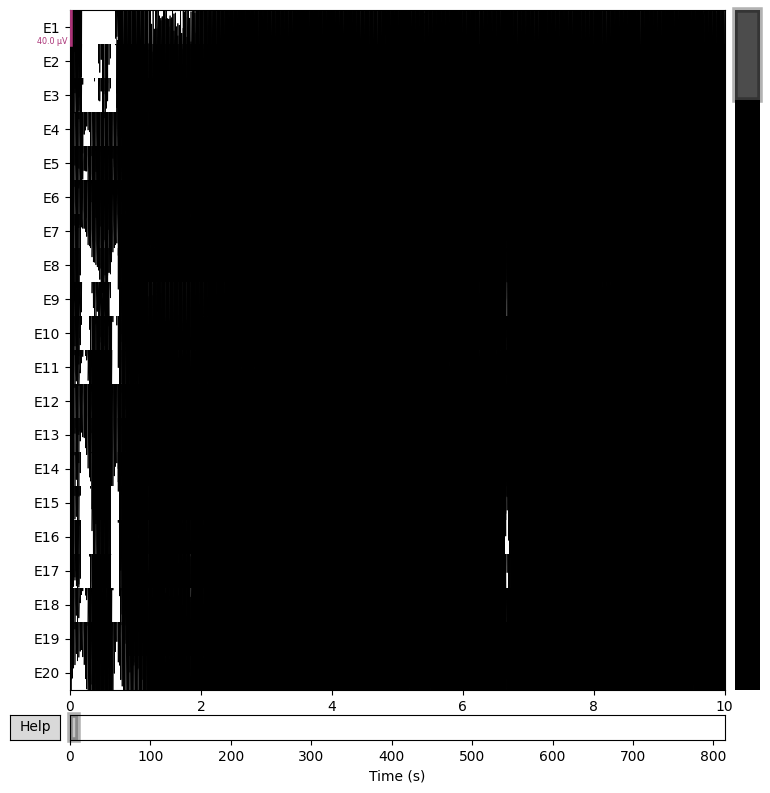

Reading EGI header from /kaggle/input/modma-dataset/EEG_128channels_ERP_lanzhou_2015/EEG_128channels_ERP_lanzhou_2015/02020026_erp 20150714 1428.raw...
    Reading events ...
    Assembling measurement info ...
    Synthesizing trigger channel "STI 014" ...
    Excluding events {SESS} ...
    Found multiple events at the same time sample. Cannot create trigger channel.
Reading 0 ... 204252  =      0.000 ...   817.008 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 1651 samples (6.604 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.5s


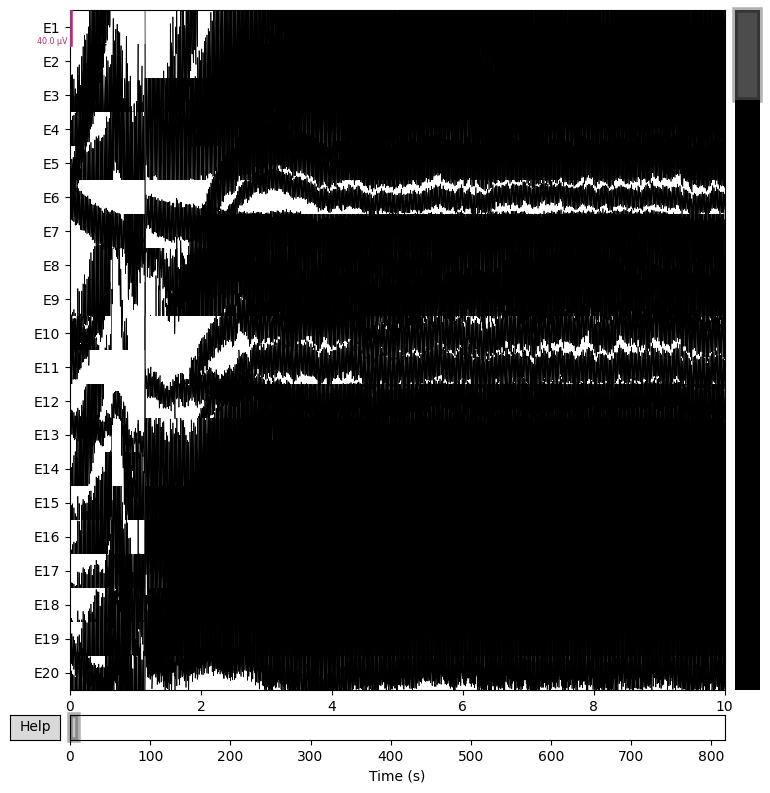

Reading EGI header from /kaggle/input/modma-dataset/EEG_128channels_ERP_lanzhou_2015/EEG_128channels_ERP_lanzhou_2015/02030004erp 20151026 2004.raw...
    Reading events ...
    Assembling measurement info ...
    Synthesizing trigger channel "STI 014" ...
    Excluding events {SESS} ...
Reading 0 ... 199339  =      0.000 ...   797.356 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 1651 samples (6.604 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.4s


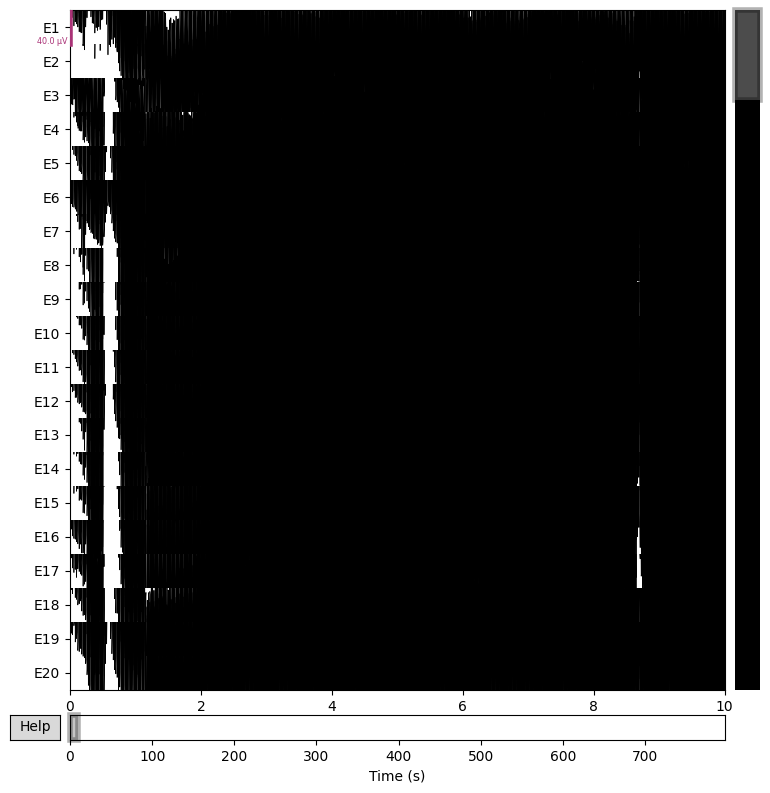

Reading EGI header from /kaggle/input/modma-dataset/EEG_128channels_ERP_lanzhou_2015/EEG_128channels_ERP_lanzhou_2015/02020027_erp 20150713 1116.raw...
    Reading events ...
    Assembling measurement info ...
    Synthesizing trigger channel "STI 014" ...
    Excluding events {SESS} ...
    Found multiple events at the same time sample. Cannot create trigger channel.
Reading 0 ... 197814  =      0.000 ...   791.256 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 1651 samples (6.604 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.4s


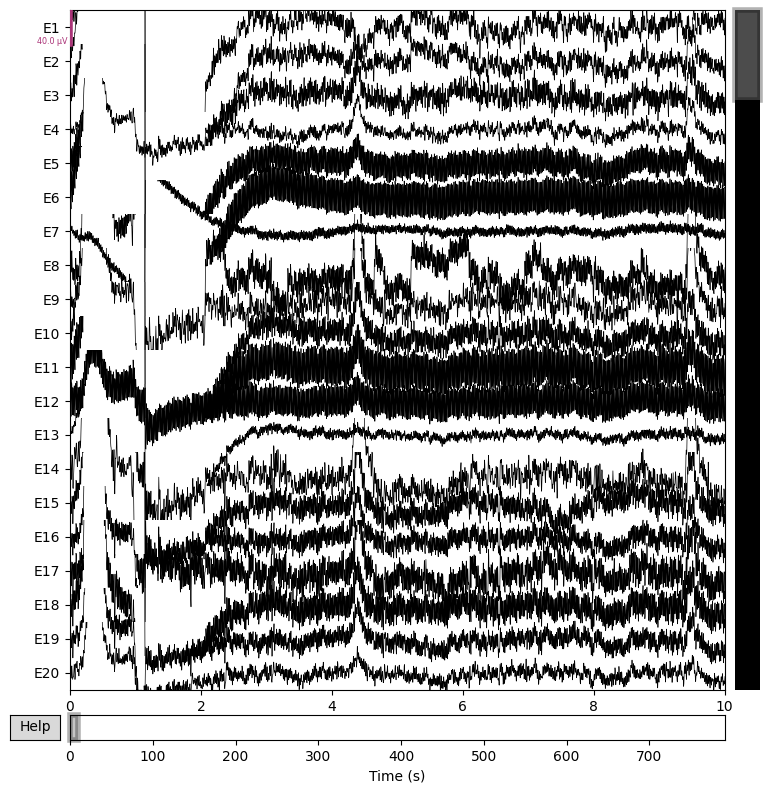

Reading EGI header from /kaggle/input/modma-dataset/EEG_128channels_ERP_lanzhou_2015/EEG_128channels_ERP_lanzhou_2015/02020025_erp 20150713 1541.raw...
    Reading events ...
    Assembling measurement info ...
    Synthesizing trigger channel "STI 014" ...
    Excluding events {SESS} ...
    Found multiple events at the same time sample. Cannot create trigger channel.
Reading 0 ... 197977  =      0.000 ...   791.908 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 1651 samples (6.604 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.4s


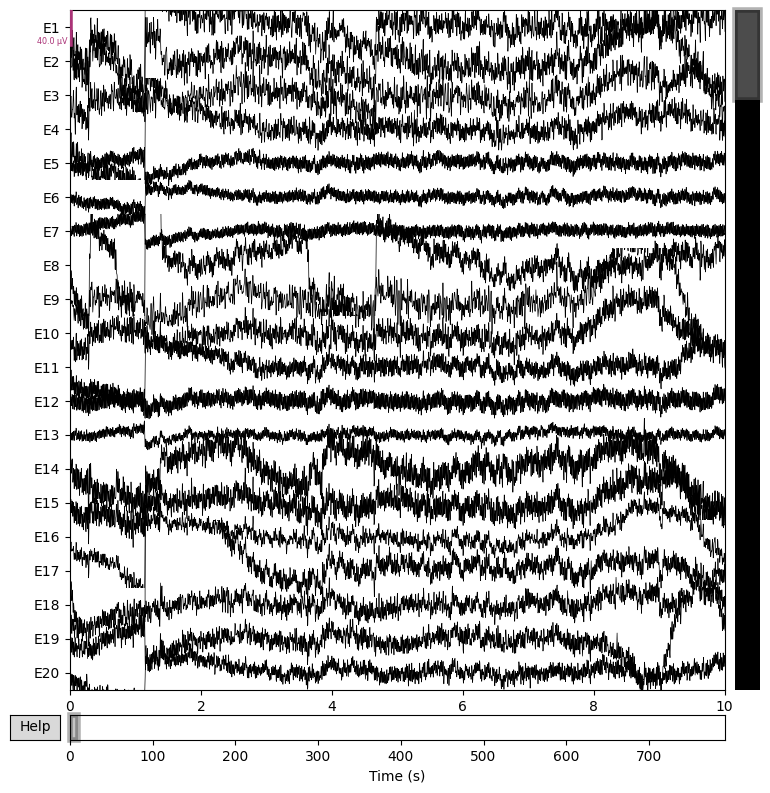

Reading EGI header from /kaggle/input/modma-dataset/EEG_128channels_ERP_lanzhou_2015/EEG_128channels_ERP_lanzhou_2015/02030021erp 20160105 1204.raw...
    Reading events ...
    Assembling measurement info ...
    Synthesizing trigger channel "STI 014" ...
    Excluding events {SESS} ...
Reading 0 ... 197977  =      0.000 ...   791.908 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 1651 samples (6.604 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.4s


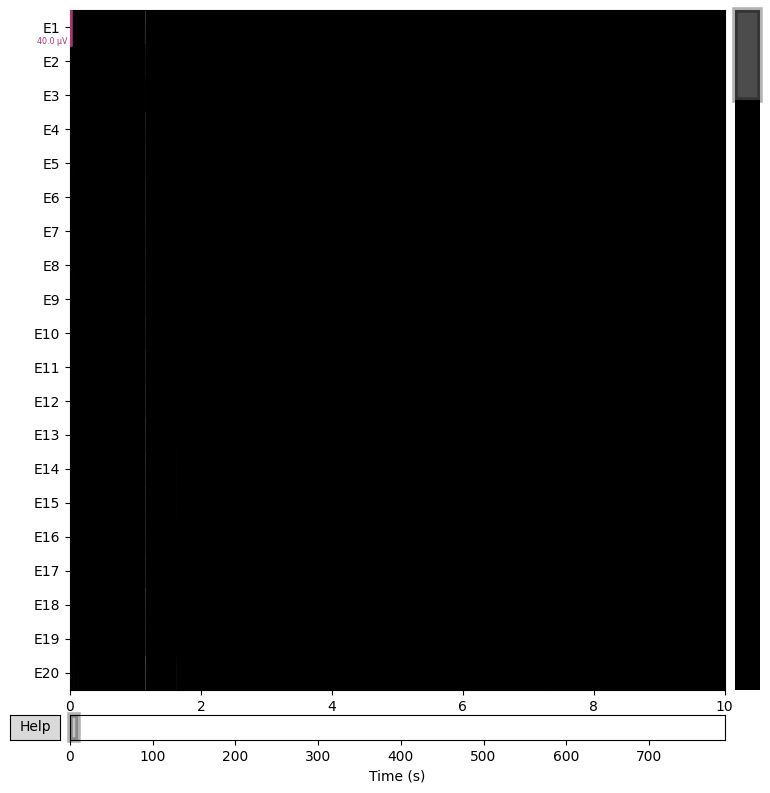

Reading EGI header from /kaggle/input/modma-dataset/EEG_128channels_ERP_lanzhou_2015/EEG_128channels_ERP_lanzhou_2015/02010022erp 20150724 1457.raw...
    Reading events ...
    Assembling measurement info ...
    Synthesizing trigger channel "STI 014" ...
    Excluding events {} ...
    Found multiple events at the same time sample. Cannot create trigger channel.
Reading 0 ... 201150  =      0.000 ...   804.600 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 1651 samples (6.604 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.4s


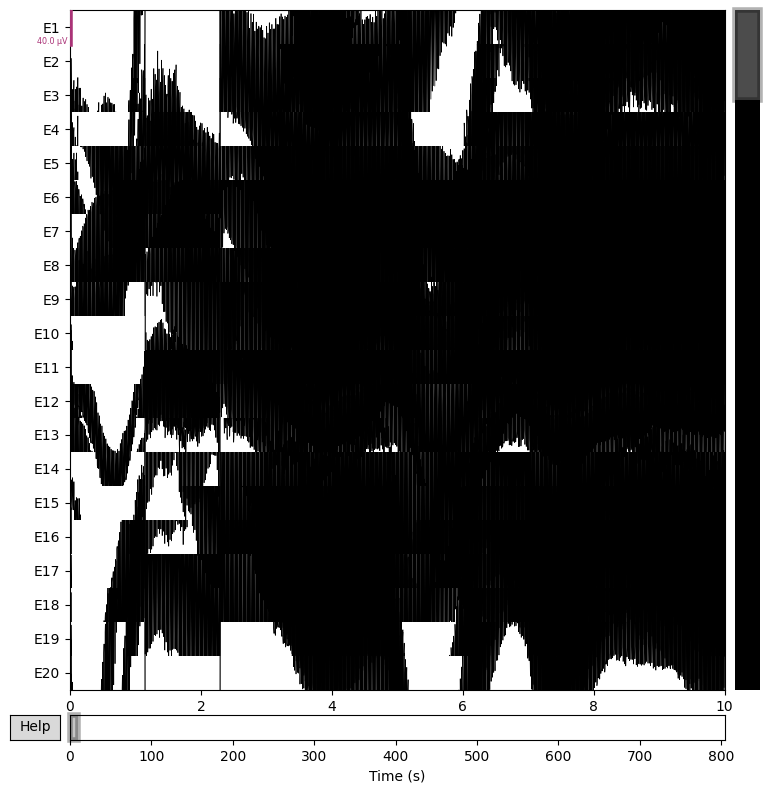

Reading EGI header from /kaggle/input/modma-dataset/EEG_128channels_ERP_lanzhou_2015/EEG_128channels_ERP_lanzhou_2015/02010023erp 20150729 1955.raw...
    Reading events ...
    Assembling measurement info ...
    Synthesizing trigger channel "STI 014" ...
    Excluding events {SESS} ...
Reading 0 ... 211052  =      0.000 ...   844.208 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 1651 samples (6.604 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.5s


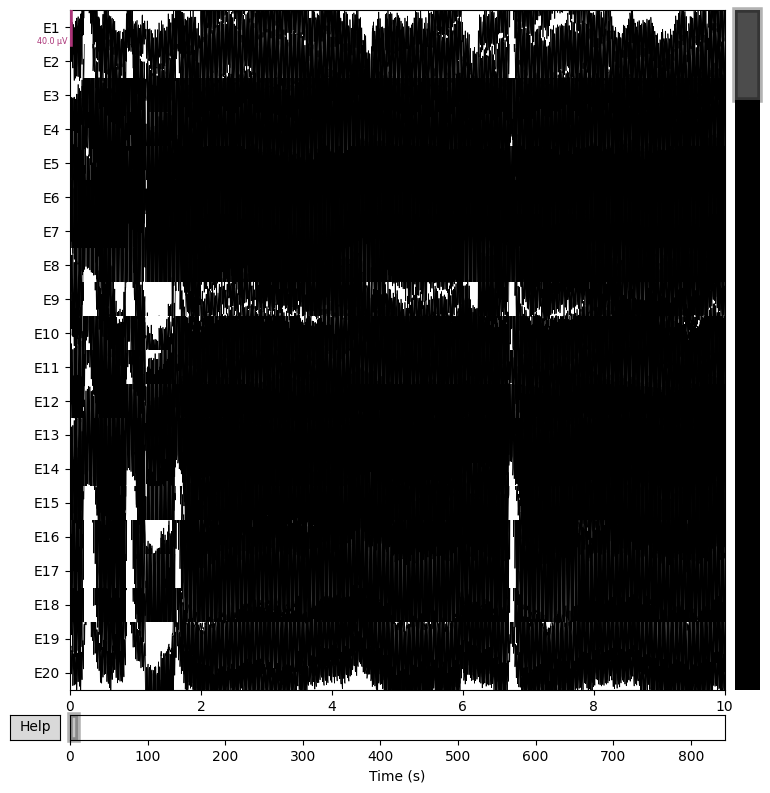

Reading EGI header from /kaggle/input/modma-dataset/EEG_128channels_ERP_lanzhou_2015/EEG_128channels_ERP_lanzhou_2015/02030005erp 20151026 2116.raw...
    Reading events ...
    Assembling measurement info ...
    Synthesizing trigger channel "STI 014" ...
    Excluding events {SESS} ...
    Found multiple events at the same time sample. Cannot create trigger channel.
Reading 0 ... 202702  =      0.000 ...   810.808 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 1651 samples (6.604 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.4s


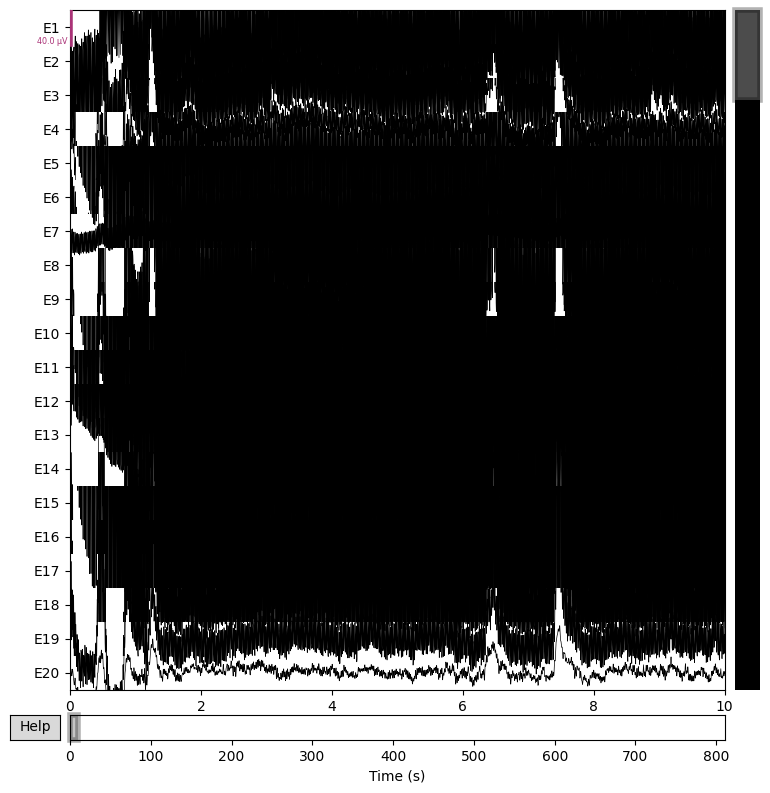

Reading EGI header from /kaggle/input/modma-dataset/EEG_128channels_ERP_lanzhou_2015/EEG_128channels_ERP_lanzhou_2015/02010011erp 20150625 1545.raw...
    Reading events ...
    Assembling measurement info ...
    Synthesizing trigger channel "STI 014" ...
    Excluding events {} ...
Reading 0 ... 214203  =      0.000 ...   856.812 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 1651 samples (6.604 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.5s


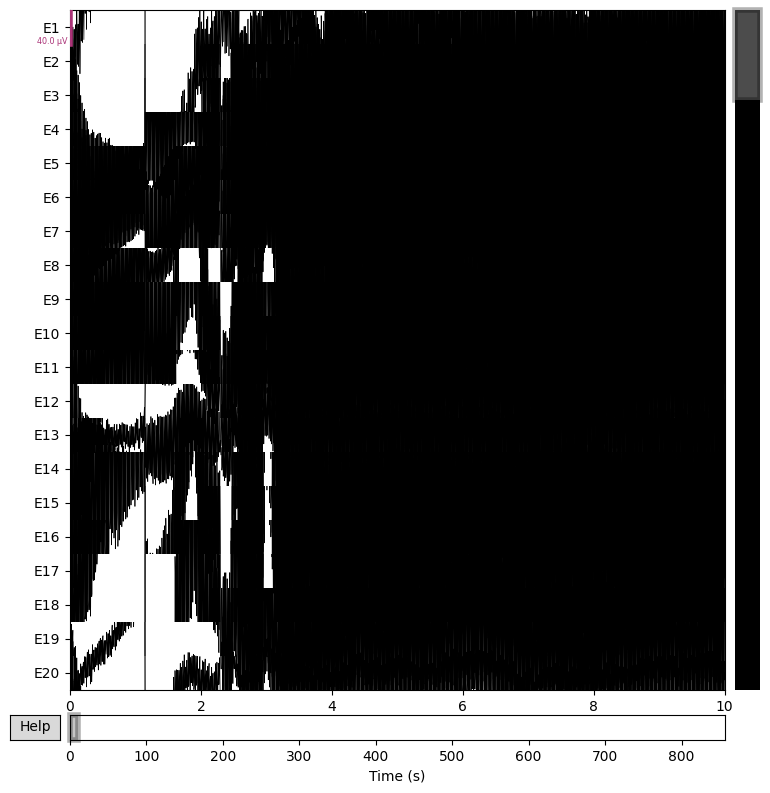

Reading EGI header from /kaggle/input/modma-dataset/EEG_128channels_ERP_lanzhou_2015/EEG_128channels_ERP_lanzhou_2015/02010034erp 20160407 0959.raw...
    Reading events ...
    Assembling measurement info ...
    Synthesizing trigger channel "STI 014" ...
    Excluding events {SESS} ...
    Found multiple events at the same time sample. Cannot create trigger channel.
Reading 0 ... 289466  =      0.000 ...  1157.864 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 1651 samples (6.604 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.7s


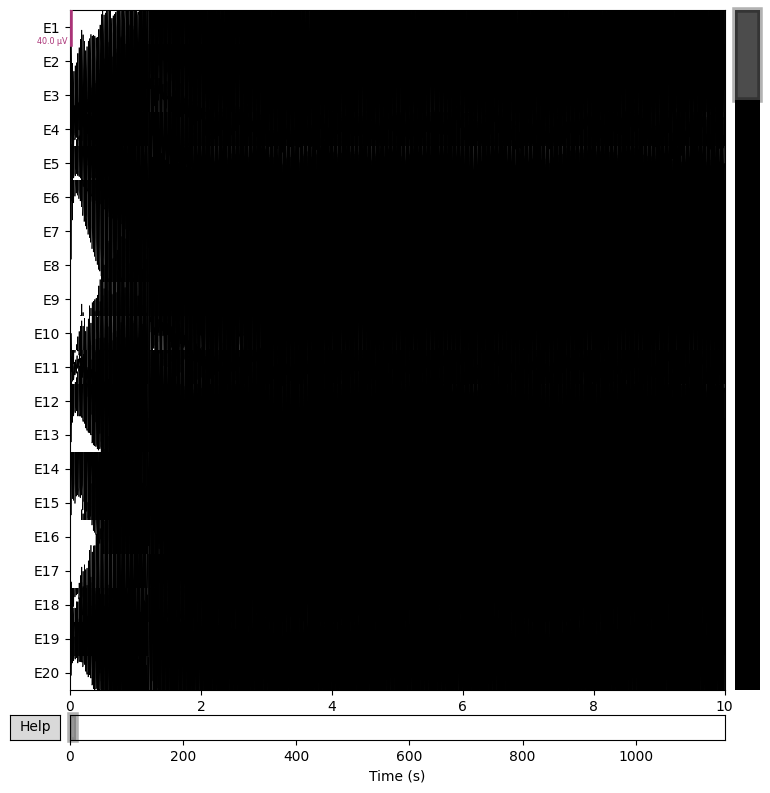

Reading EGI header from /kaggle/input/modma-dataset/EEG_128channels_ERP_lanzhou_2015/EEG_128channels_ERP_lanzhou_2015/02030002erp_new 20151022 14.raw...
    Reading events ...
    Assembling measurement info ...
    Synthesizing trigger channel "STI 014" ...
    Excluding events {SESS} ...
    Found multiple events at the same time sample. Cannot create trigger channel.
Reading 0 ... 196128  =      0.000 ...   784.512 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 1651 samples (6.604 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.5s


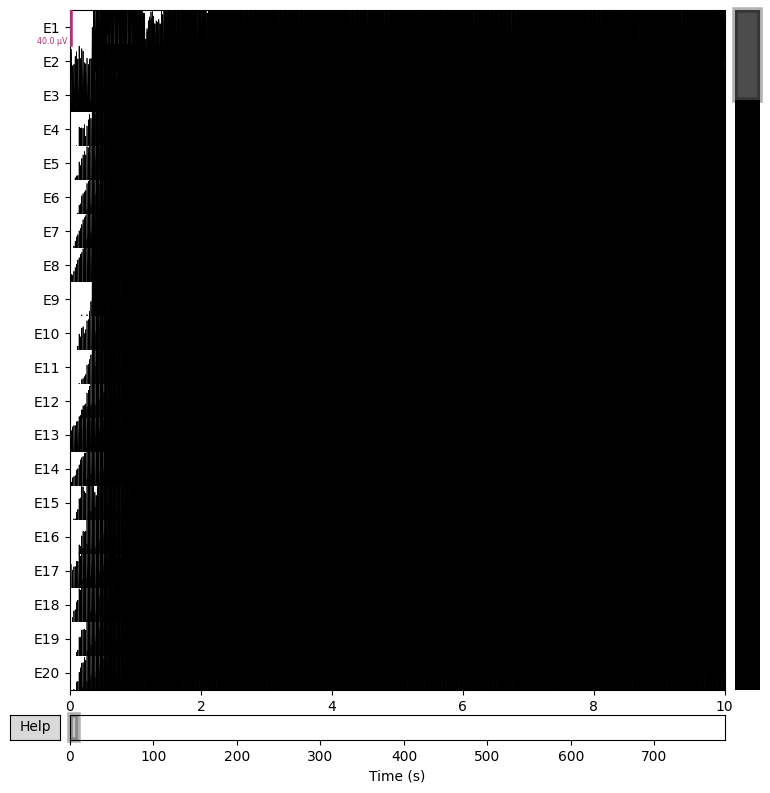

Reading EGI header from /kaggle/input/modma-dataset/EEG_128channels_ERP_lanzhou_2015/EEG_128channels_ERP_lanzhou_2015/02010019erp 20150716 1544.raw...
    Reading events ...
    Assembling measurement info ...
    Synthesizing trigger channel "STI 014" ...
    Excluding events {SESS} ...
    Found multiple events at the same time sample. Cannot create trigger channel.
Reading 0 ... 196038  =      0.000 ...   784.152 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 1651 samples (6.604 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.5s


KeyboardInterrupt: 

In [13]:
import os
import mne
import matplotlib.pyplot as plt

# Define input and output directory paths
input_dir = '/kaggle/input/modma-dataset/EEG_128channels_ERP_lanzhou_2015/EEG_128channels_ERP_lanzhou_2015'

# Iterate through each file in the input directory
for filename in os.listdir(input_dir):
    if filename.endswith('.raw'):
        # Load raw data
        raw = mne.io.read_raw_egi(os.path.join(input_dir, filename), preload=True)
        
        # Apply preprocessing steps (example: filtering)
        raw.filter(0.5, 45, fir_design='firwin')
        
        # Set channel types if necessary
        channel_types = {ch_name: 'eeg' for ch_name in raw.ch_names if ch_name.startswith('EEG')}
        raw.set_channel_types(channel_types)
        
        # Plot sensors and save as an image file
        fig = raw.plot()
        fig.savefig(f'sensors_plot_{filename[:-4]}.png')  # Save plot with a specific filename
        
        # Close the figure to free up memory
        plt.close(fig)


# **MAT-128-CHANNEL-PREPROCESSING**

In [15]:
import os
import mne
import scipy.io

# Define input and output directory paths
input_dir = '/kaggle/input/modma-dataset/EEG_128channels_resting_lanzhou_2015/EEG_128channels_resting_lanzhou_2015'
output_dir = '/kaggle/working/processed_mat_data/'  # Define your desired output directory

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Iterate through each file in the input directory
for filename in os.listdir(input_dir):
    if filename.endswith('.mat'):
        # Load mat file
        mat_data = scipy.io.loadmat(os.path.join(input_dir, filename))
        
        # Extract EEG data and other necessary information from mat file
        # Replace with actual data extraction based on your mat file structure
        eeg_data = mat_data['Impendances_0']
        sampling_rate = mat_data['samplingRate']
        
        # Create MNE info structure
        ch_names = ['EEG 001', 'EEG 002', 'EEG 003']  # Replace with actual channel names
        info = mne.create_info(ch_names=ch_names, sfreq=sampling_rate, ch_types='eeg')
        
        # Create RawArray from EEG data and info
        raw = mne.io.RawArray(eeg_data, info)
        
        # Apply preprocessing steps (example: filtering)
        raw.filter(0.5, 45, fir_design='firwin')
        
        # Save processed data to the output directory with .fif extension
        processed_filename = os.path.join(output_dir, f'processed_{os.path.splitext(filename)[0]}.fif')
        raw.save(processed_filename, overwrite=True)


KeyError: 'Impendances_0'

In [18]:
import os
import mne
import scipy.io

# Define input and output directory paths
input_dir = '/kaggle/input/modma-dataset/EEG_128channels_resting_lanzhou_2015/EEG_128channels_resting_lanzhou_2015'
output_dir = '/kaggle/working/processed_mat_data/'  # Define your desired output directory

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Iterate through each file in the input directory
for filename in os.listdir(input_dir):
    if filename.endswith('.mat'):
        # Load mat file
        mat_data = scipy.io.loadmat(os.path.join(input_dir, filename))
        
        # Example: Print keys to inspect the structure of mat_data
        print(f"Keys in {filename}: {mat_data.keys()}")
        
        # Extract EEG data and sampling rate from mat file
        # Replace with the correct keys based on your mat file structure
        eeg_data = mat_data[3]  # Replace 'your_eeg_data_key' with the correct key
        sampling_rate = mat_data['samplingRate']  # Replace 'your_sampling_rate_key' with the correct key
        
        # Create MNE info structure
        ch_names = ['EEG 001', 'EEG 002', 'EEG 003']  # Replace with actual channel names
        info = mne.create_info(ch_names=ch_names, sfreq=sampling_rate, ch_types='eeg')
        
        # Create RawArray from EEG data and info
        raw = mne.io.RawArray(eeg_data, info)
        
        # Apply preprocessing steps (example: filtering)
        raw.filter(0.5, 45, fir_design='firwin')
        
        # Save processed data to the output directory with .fif extension
        processed_filename = os.path.join(output_dir, f'processed_{os.path.splitext(filename)[0]}.fif')
        raw.save(processed_filename, overwrite=True)


Keys in 02030007_rest 20151103 2032.mat: dict_keys(['__header__', '__version__', '__globals__', 'a02030007_rest_20151103_2032mat', 'samplingRate', 'Impedances_0'])


KeyError: 3

In [22]:
import scipy.io

# Load mat file
mat_data = scipy.io.loadmat('/kaggle/input/modma-dataset/EEG_128channels_resting_lanzhou_2015/EEG_128channels_resting_lanzhou_2015/02010015rest 20150709 1456..mat')

# Print keys in mat_data
print(mat_data.keys())
for key in mat_data.keys():
    print(f"Key: {key}, Shape: {mat_data[key]}")


dict_keys(['__header__', '__version__', '__globals__', 'a02010015rest_20150709_1456mat', 'samplingRate', 'Impedances_0'])
Key: __header__, Shape: b'Net Station 4.0 MAT-file, Platform: MAC2, Created on: 160810/20:02:48.000'
Key: __version__, Shape: 1.0
Key: __globals__, Shape: []
Key: a02010015rest_20150709_1456mat, Shape: [[ -9641.04101562  -9609.58398438  -9672.55664062 ...  -6949.7109375
   -6846.4453125   -6835.74951172]
 [-11746.81347656 -11760.1640625  -11786.90234375 ...  -5741.41357422
   -5689.96826172  -5710.58056641]
 [-23440.12109375 -23455.37695312 -23423.80664062 ... -19116.7578125
  -19170.18945312 -19173.3515625 ]
 ...
 [-17742.94921875 -17764.1640625  -17780.37304688 ... -14956.97558594
  -14911.27246094 -14920.48046875]
 [-18451.38085938 -18458.43945312 -18479.91210938 ... -13183.14941406
  -13120.55078125 -13118.72949219]
 [     0.              0.              0.         ...      0.
       0.              0.        ]]
Key: samplingRate, Shape: [[250.]]
Key: Impedances

In [23]:
import os
import mne
import scipy.io

# Define input and output directory paths
input_dir = '/kaggle/input/modma-dataset/EEG_128channels_resting_lanzhou_2015/EEG_128channels_resting_lanzhou_2015'
output_dir = '/kaggle/working/processed_mat_data/'  # Define your desired output directory

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Iterate through each file in the input directory
for filename in os.listdir(input_dir):
    if filename.endswith('.mat'):
        # Load mat file
        mat_data = scipy.io.loadmat(os.path.join(input_dir, filename))
        
        # Print keys in mat_data for inspection
        print(f"Keys in {filename}: {mat_data.keys()}")
        
        # Example: Extract EEG data from the first array-like key found
        eeg_data_key = None
        for key in mat_data.keys():
            if isinstance(mat_data[key], (list, np.ndarray)) and mat_data[key].ndim == 2:
                eeg_data = mat_data[key]
                eeg_data_key = key
                break
        
        if eeg_data_key is None:
            print(f"No suitable EEG data found in {filename}. Skipping...")
            continue
        
        # Assuming sampling rate is stored in 'samplingRate' key
        sampling_rate = float(mat_data['samplingRate'][0, 0])
        
        # Ensure EEG data is in the expected format (channels x samples)
        eeg_data = eeg_data.T  # Transpose if necessary
        
        # Create MNE info structure
        ch_names = ['EEG 001', 'EEG 002', 'EEG 003']  # Replace with actual channel names
        info = mne.create_info(ch_names=ch_names, sfreq=sampling_rate, ch_types='eeg')
        
        # Create RawArray from EEG data and info
        raw = mne.io.RawArray(eeg_data, info)
        
        # Apply preprocessing steps (example: filtering)
        raw.filter(0.5, 45, fir_design='firwin')
        
        # Save processed data to the output directory with .fif extension
        processed_filename = os.path.join(output_dir, f'processed_{os.path.splitext(filename)[0]}.fif')
        raw.save(processed_filename, overwrite=True)


Keys in 02030007_rest 20151103 2032.mat: dict_keys(['__header__', '__version__', '__globals__', 'a02030007_rest_20151103_2032mat', 'samplingRate', 'Impedances_0'])


AttributeError: 'list' object has no attribute 'ndim'

In [24]:
import os
import mne
import scipy.io
import numpy as np

# Define input and output directory paths
input_dir = '/kaggle/input/modma-dataset/EEG_128channels_resting_lanzhou_2015/EEG_128channels_resting_lanzhou_2015'
output_dir = '/kaggle/working/processed_mat_data/'  # Define your desired output directory

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Iterate through each file in the input directory
for filename in os.listdir(input_dir):
    if filename.endswith('.mat'):
        # Load mat file
        mat_data = scipy.io.loadmat(os.path.join(input_dir, filename))
        
        # Print keys in mat_data for inspection
        print(f"Keys in {filename}: {mat_data.keys()}")
        
        # Example: Extract EEG data from the first suitable key found
        eeg_data = None
        eeg_data_key = None
        
        for key in mat_data.keys():
            if isinstance(mat_data[key], (np.ndarray, list)) and len(mat_data[key]) > 0:
                if isinstance(mat_data[key][0], (np.ndarray, list)) and len(mat_data[key][0]) > 0:
                    eeg_data = mat_data[key]
                    eeg_data_key = key
                    break
        
        if eeg_data is None:
            print(f"No suitable EEG data found in {filename}. Skipping...")
            continue
        
        # Assuming sampling rate is stored in 'samplingRate' key
        sampling_rate = float(mat_data['samplingRate'][0, 0])
        
        # Ensure EEG data is in the expected format (channels x samples)
        eeg_data = np.array(eeg_data).T  # Transpose if necessary
        
        # Create MNE info structure
        ch_names = ['EEG 001', 'EEG 002', 'EEG 003']  # Replace with actual channel names
        info = mne.create_info(ch_names=ch_names, sfreq=sampling_rate, ch_types='eeg')
        
        # Create RawArray from EEG data and info
        raw = mne.io.RawArray(eeg_data, info)
        
        # Apply preprocessing steps (example: filtering)
        raw.filter(0.5, 45, fir_design='firwin')
        
        # Save processed data to the output directory with .fif extension
        processed_filename = os.path.join(output_dir, f'processed_{os.path.splitext(filename)[0]}.fif')
        raw.save(processed_filename, overwrite=True)


Keys in 02030007_rest 20151103 2032.mat: dict_keys(['__header__', '__version__', '__globals__', 'a02030007_rest_20151103_2032mat', 'samplingRate', 'Impedances_0'])


ValueError: len(data) (75750) does not match len(info["ch_names"]) (3)

In [4]:
!pip install mne scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 36.0 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 23.0.1 -> 24.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import mne
import scipy.io
import numpy as np

# Define input and output directory paths
input_dir = '/kaggle/input/modma-dataset-2/EEG_128channels_resting_lanzhou_2015/EEG_128channels_resting_lanzhou_2015'
output_dir = '/kaggle/working/processed_mat_data2/'  # Define your desired output directory

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Iterate through each file in the input directory
for filename in os.listdir(input_dir):
    if filename.endswith('.mat'):
        # Load mat file
        mat_data = scipy.io.loadmat(os.path.join(input_dir, filename))
        
        # Print keys in mat_data for inspection
        print(f"Keys in {filename}: {mat_data.keys()}")
        
        # Example: Extract EEG data from the first suitable key found
        eeg_data = None
        eeg_data_key = None
        
        for key in mat_data.keys():
            if isinstance(mat_data[key], (np.ndarray, list)) and len(mat_data[key]) > 0:
                if isinstance(mat_data[key][0], (np.ndarray, list)) and len(mat_data[key][0]) > 0:
                    eeg_data = mat_data[key]
                    eeg_data_key = key
                    break
        
        if eeg_data is None:
            print(f"No suitable EEG data found in {filename}. Skipping...")
            continue
        
        # Assuming sampling rate is stored in 'samplingRate' key
        sampling_rate = float(mat_data['samplingRate'][0, 0])
        
        # Ensure EEG data is in the expected format (channels x samples)
        eeg_data = np.array(eeg_data).T  # Transpose if necessary
        
        # Determine number of channels from EEG data shape
        n_channels = eeg_data.shape[0]
        
        # Create channel names based on the number of channels
        ch_names = [f'EEG {i+1:03}' for i in range(n_channels)]
        
        # Create MNE info structure
        info = mne.create_info(ch_names=ch_names, sfreq=sampling_rate, ch_types='eeg')
        
        # Create RawArray from EEG data and info
        raw = mne.io.RawArray(eeg_data, info)
        
        # Apply preprocessing steps (example: filtering)
        raw.filter(0.5, 45, fir_design='firwin')
        
        # Save processed data to the output directory with .fif extension
        processed_filename = os.path.join(output_dir, f'processed_{os.path.splitext(filename)[0]}.fif')
        raw.save(processed_filename, overwrite=True)


Keys in 02030007_rest 20151103 2032.mat: dict_keys(['__header__', '__version__', '__globals__', 'a02030007_rest_20151103_2032mat', 'samplingRate', 'Impedances_0'])
Creating RawArray with float64 data, n_channels=75750, n_times=129
    Range : 0 ... 128 =      0.000 ...     0.512 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 1651 samples (6.604 s)



/tmp/ipykernel_33/2653124871.py:56: RuntimeWarning: filter_length (1651) is longer than the signal (129), distortion is likely. Reduce filter length or filter a longer signal.
  raw.filter(0.5, 45, fir_design='firwin')
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 647 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 881 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 1151 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 1457 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 1799 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done 2177 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done 2591 tasks      | elapsed:    0.6s
[Parallel(n_jobs=1)]: Done 3041 tasks      |

KeyboardInterrupt: 

In [3]:
!zip -r raw-128-channel-preprocessed-output.zip /kaggle/working/processed_raw_data

  adding: kaggle/working/processed_raw_data/ (stored 0%)
  adding: kaggle/working/processed_raw_data/processed_02020023_erpnew 20150709 110.fif (deflated 21%)
  adding: kaggle/working/processed_raw_data/processed_02010028erp 20160317 1554.fif (deflated 21%)
  adding: kaggle/working/processed_raw_data/processed_02020029_erp 20150715 1401.fif (deflated 21%)
  adding: kaggle/working/processed_raw_data/processed_02020008_erp 20150624 1740.fif (deflated 20%)
  adding: kaggle/working/processed_raw_data/processed_02020020_erp 20150703 1810.fif (deflated 20%)
  adding: kaggle/working/processed_raw_data/processed_02010008_erp(n) 20150619 1709.fif (deflated 21%)
  adding: kaggle/working/processed_raw_data/processed_02030006 20151103 1801.fif (deflated 20%)
  adding: kaggle/working/processed_raw_data/processed_02020013_erp 20150629 1622.fif (deflated 21%)
  adding: kaggle/working/processed_raw_data/processed_02030007 20151103 2129.fif (deflated 21%)
  adding: kaggle/working/processed_raw_data/pro

In [1]:
from IPython.display import FileLink
FileLink(r'raw-128-channel-preprocessed-output.zip')

/kaggle/working/raw-128-channel-preprocessed-output.zip

In [2]:
!ls

 processed_mat_data
 processed_raw_data
 raw-128-channel-preprocessed-output.zip
'sensors_plot_02010011erp 20150625 1545.png'
'sensors_plot_02010012erp 20150626 1059.png'
'sensors_plot_02010022erp 20150724 1457.png'
'sensors_plot_02010023erp 20150729 1955.png'
'sensors_plot_02010034erp 20160407 0959.png'
'sensors_plot_02020025_erp 20150713 1541.png'
'sensors_plot_02020026_erp 20150714 1428.png'
'sensors_plot_02020027_erp 20150713 1116.png'
'sensors_plot_02030002erp_new 20151022 14.png'
'sensors_plot_02030004erp 20151026 2004.png'
'sensors_plot_02030005erp 20151026 2116.png'
'sensors_plot_02030021erp 20160105 1204.png'
 state.db
